<div style="padding: 20px; background-color: #f0f7ff; border-left: 10px solid #0056b3; text-align: center;">
    <h1 style="color: #0056b3;">🎓 CPLEX 调研</h1>
    <h3>2025年12月19日</h3>
</div>

<div style="background-color: #f8fafc; border: 1px solid #e2e8f0; border-radius: 16px; padding: 25px; box-shadow: 0 4px 15px rgba(0,0,0,0.05);">
<div style="border-left: 5px solid #2563eb; padding-left: 15px; margin-bottom: 20px;">
<h2 style="color: #1e293b; margin: 0; border: none; font-size: 24px;">📖 目录</h2>
</div>
<div style="margin-bottom: 10px; padding: 12px; background: white; border-radius: 8px; border: 1px solid #f1f5f9;">
<b style="color: #2563eb;">01.</b> CPLEX简介
</div>
<div style="margin-bottom: 10px; padding: 12px; background: white; border-radius: 8px; border: 1px solid #f1f5f9;">
<b style="color: #2563eb;">02.</b> CPLEX Python API
</div>
<div style="margin-bottom: 10px; padding: 12px; background: white; border-radius: 8px; border: 1px solid #f1f5f9;">
<b style="color: #2563eb;">03.</b> 案例
</div>
</div>

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 12px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); overflow: hidden; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: #8ca4f3ff; padding: 15px 25px;">
        <h2 style="color: #ffffff; margin: 0; border: none; font-size: 24px; letter-spacing: 1px;">
            1 CPLEX简介
        </h2>
    </div>
    <div style="padding: 25px; line-height: 1.8; color: #334155;">
        <div style="margin-bottom: 20px;">
            <b style="color: #1e40af; font-size: 1.1em;">1. 特点</b><br>CPLEX 是 IBM 开发的一款世界顶级数学规划求解器，以算法稳定、求解速度极快、能够处理数百万级变量的大规模工业问题而著称。
        </div>
        <div style="margin-bottom: 20px;">
            <b style="color: #1e40af; font-size: 1.1em;">2. 支持的问题</b><br>
            线性规划（LP）、混合整数规划（MIP）、二次规划（QP）、组合规划（CP）
        </div>
        <div style="margin-bottom: 20px;">
            <b style="color: #1e40af; font-size: 1.1em;">2. 参考资料</b><br>
            Python API 官方文档：https://ibmdecisionoptimization.github.io/docplex-doc/<br>案例：https://github.com/IBMDecisionOptimization/docplex-examples
        </div>
</div>

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 12px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); overflow: hidden; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: #8ca4f3ff; padding: 15px 25px;">
        <h2 style="color: #ffffff; margin: 0; border: none; font-size: 24px; letter-spacing: 1px;">
            2 CPLEX Python API
        </h2>
    </div>
    <div style="padding: 25px; line-height: 1.8; color: #334155;">
        <div style="margin-bottom: 20px;">
            <b style="color: #1e40af; font-size: 1.1em;">环境配置</b><br>Python >= 3.6
            <pre style="background: #696d73ff; color: #f8fafc; padding: 15px; border-radius: 8px; margin-top: 10px; font-family: 'Courier New', Courier, monospace;">
pip install docplex, cplex</pre>
    </div>
        <div style="margin-bottom: 20px;">
            <b style="color: #1e40af; font-size: 1.1em;">两大模块</b><br>
            docplex.mp : Mathematical Programming<br>docplex.cp : Constraint Programming
        </div>
</div>

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 12px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); overflow: hidden; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: #8ca4f3ff; padding: 15px 25px;">
        <h2 style="color: #ffffff; margin: 0; border: none; font-size: 24px; letter-spacing: 1px;">
            2.1 docplex.mp API
        </h2>
</div>

In [ ]:
## mp 模块
# --- 初始化 ---
from docplex.mp.model import Model
mdl = Model(name='CPLEX_Cheat_Sheet')

# --- 变量创建 ---
mdl.continuous_var(lb=0, ub=None, name='x')    # 创建连续变量
mdl.binary_var(name='b')                       # 创建0-1变量
mdl.integer_var(lb=0, ub=10, name='i')         # 创建整数变量
mdl.continuous_var_dict(keys=['a', 'b'], name='vd') # 批量创建变量字典
mdl.binary_var_matrix(keys1=[1,2], keys2=[3,4], name='m') # 创建变量矩阵

In [ ]:
# --- 约束与目标 ---
mdl.add_constraint(mdl.sum([mdl.binary_var()]) <= 1) # 添加单条约束
mdl.add_constraints([mdl.continuous_var() >= 0])     # 批量添加约束
mdl.minimize(mdl.sum([mdl.integer_var()]))           # 设置最小化目标
mdl.maximize(10)                                     # 设置最大化目标
# --- 操作与输出 ---
mdl.solve()                     # 启动求解
mdl.print_information()         # 打印模型统计信息（变量、约束数量等）
mdl.print_solution()            # 打印所有非零变量的解
mdl.export_as_lp(path='model.lp') # 导出为LP文件
mdl.clear()                     # 清空模型所有内容

In [ ]:
# --- 模型状态属性 ---
mdl.name                # 获取/设置模型名称
mdl.objective_value     # 获取最优解的目标函数值 (需在solve后使用)
mdl.objective_expr      # 获取目标函数的代数表达式
mdl.solution            # 获取整个解对象 (docplex.mp.solution.SolveSolution)
mdl.solve_details       # 获取求解细节对象（包含时间、Gap、状态等）

# --- 统计属性 (只读) ---
mdl.number_of_variables           # 获取模型中变量的总数
mdl.number_of_binary_variables    # 获取 0-1 变量的数量
mdl.number_of_constraints         # 获取约束的总数
mdl.number_of_linear_constraints  # 获取线性约束的数量

# --- 求解状态属性 (通过 solve_details 访问) ---
mdl.solve_details.time          # 求解消耗的 CPU 时间
mdl.solve_details.status        # 求解的状态描述（如 'integer optimal solution'）
mdl.solve_details.mip_relative_gap # 获取 MIP 问题的相对间隙 (Gap)

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 12px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); overflow: hidden; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: #8ca4f3ff; padding: 15px 25px;">
        <h2 style="color: #ffffff; margin: 0; border: none; font-size: 24px; letter-spacing: 1px;">
            2.2 docplex.cp API
        </h2>
</div>

In [13]:
# ---  初始化 ---
from docplex.cp.model import CpoModel
cp_mdl = CpoModel(name='CP_Scheduling_Model')

In [ ]:
# --- 变量创建  ---
cp_mdl.integer_var(min=0, max=100, name='i')      # 创建有界整数变量
cp_mdl.binary_var(name='b')                       # 创建0-1变量
cp_mdl.sequence_var([cp_mdl.interval_var()], name='seq') # 创建序列变量 (任务排序)

# 创建区间变量
cp_mdl.interval_var(start=None, end=None, length=None, size=None, name='task')
# 表示一个持续时间固定为 10 个单位的任务
task1 = cp_mdl.interval_var(size=10, name="Task1")
# 必须在时间点 0 和 50 之间完成的任务，持续时间由系统在 [5, 10] 之间决定
task2 = cp_mdl.interval_var(start=(0, 50), end=(0, 50), size=(5, 10), name="Task2")
# 强制要求该任务必须在 100 时刻准时开始
task3 = mdl.interval_var(start=100, size=15)

In [ ]:
# --- 逻辑与约束 ---
cp_mdl.add(cp_mdl.all_diff([cp_mdl.integer_var()])) # 添加约束 (注意 CP 常用 add 而不是 add_constraint)
cp_mdl.add(cp_mdl.if_then(cp_mdl.binary_var(), cp_mdl.integer_var() > 5)) # 逻辑约束
cp_mdl.minimize(cp_mdl.integer_var())               # 目标函数最小化

# --- 求解与输出 ---
sol = cp_mdl.solve(TimeLimit=10) # 启动求解，可设置参数
cp_mdl.export_model(out='model.cpo') # 导出为 .cpo 格式文件
cp_mdl.print_information()      # 打印模型统计信息

<div style="margin-bottom: 20px;">
            <b style="color: #1e40af; font-size: 1.1em;">cp 特有的约束</b><br>
        </div>
</div>

In [ ]:
# 全局约束
all_diff(vars) # 确保列表中的所有变量取值互不相同（经典用于 N 皇后或数独）
count(vars, value) == k # 统计变量列表中取值为某个特定值的次数
allowed_assignments(vars, tuple_set) # 允许约束：变量的取值组合必须在给定的元组集合中（类似白名单）
forbidden_assignments(vars, tuple_set) # 禁止约束：变量的取值组合不能出现在给定集合中（类似黑名单）
inverse(vars1, vars2) # 双向索引约束：若 vars1[i]=j，则 vars2[j]=i

# 调度与区间约束
start_before_start(v1, v2) # 约束任务 1 必须在任务 2 开始之前开始
end_before_start(v1, v2, delay=0) # 标准紧前关系：任务 1 结束后，任务 2 才能开始（可加延迟）
overlap_length(v1, v2) # 计算两个任务在时间轴上重叠的长度
no_overlap(sequence_var) # 序列约束：确保一组任务在同一台机器上互不重叠（自动处理排序）
span(v_parent, [v_children]) # 跨度约束：父任务的开始时间等于子任务的最早开始，结束时间等于子任务的最晚结束
alternative(v_parent, [v_children]) # 备选约束：在一组可选的子任务中恰好选择一个执行（常用于多机选择）
synchronize(v_parent, [v_children]) # 同步约束：所有子任务必须与父任务同时开始和结束

In [ ]:
# 逻辑与表达式约束
if_then(condition, outcome) # 逻辑蕴含：如果条件成立，则执行结果。
logical_and([...]) / logical_or([...]) # 复杂的布尔逻辑组合。
element(array, index_var) # 索引约束：从数组中提取第 index_var 个元素的值，其中索引本身是一个变量
# 资源容量约束
pulse(interval_var, height) # 在任务执行期间，瞬时占用固定高度的资源
always_in(state_function, interval_var, min_v, max_v) # 状态约束：在某个任务执行期间，某种状态（如温度）必须保持在范围内
cumul_range(cumul_expr, min_v, max_v) # 累积资源约束：确保在任何时间点，所有任务占用的资源总和不超过上限

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 12px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); overflow: hidden; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: #8ca4f3ff; padding: 15px 25px;">
        <h2 style="color: #ffffff; margin: 0; border: none; font-size: 24px; letter-spacing: 1px;">
            3 案例
        </h2>
</div>

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 12px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); overflow: hidden; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: #c1cdf5ff; padding: 15px 25px;">
        <h2 style="color: #ffffff; margin: 0; border: none; font-size: 24px; letter-spacing: 1px;">
            3.1 案例1
        </h2>
</div>

<div style="padding: 20px; border: 1px solid #e0e0e0; border-radius: 8px; background-color: #f9f9f9; line-height: 1.6; font-family: 'Microsoft YaHei', sans-serif;">
    <h2 style="color: #0056b3; border-bottom: 2px solid #0056b3; padding-bottom: 10px;">橄榄球联盟 (NFL) 赛程安排问题</h2>
    <p>一个拥有两个分区的体育联盟必须安排比赛，使得每个球队与<strong>同分区</strong>内的所有球队比赛指定次数，并与<strong>不同分区</strong>的球队也比赛指定次数。</p>
    <ul style="list-style-type: square; margin-left: 20px;">
        <li>每支球队每周<strong>恰好参加一场</strong>比赛。</li>
        <li>同一对球队<strong>不能在连续的两周内</strong>互相对阵。</li>
    </ul>
    <h3 style="color: #2c3e50;">赛程偏好与激励机制：</h3>
    <p>规定每支球队<strong>三分之一的同分区内比赛</strong>必须在赛季前半段进行(硬),<p>但实际偏好是希望<strong>同分区内对决尽可能安排在赛季末期</strong>（软）。</p>
    <p>为了模拟这一偏好，系统为同分区比赛设置了激励值，该值随周数的<strong>平方</strong>逐周增加。我们的目标是为每支球队每周分配一名对手，以实现<strong>总激励值最大化</strong>。</p>
</div>


In [1]:
# 分区1的队伍
team_div1 = ["Baltimore Ravens","Cincinnati Bengals", "Cleveland Browns","Pittsburgh Steelers","Houston Texans",
                "Indianapolis Colts","Jacksonville Jaguars","Tennessee Titans","Buffalo Bills","Miami Dolphins",
                "New England Patriots","New York Jets","Denver Broncos","Kansas City Chiefs","Oakland Raiders",
                "San Diego Chargers"]
# 分区2的队伍
team_div2 = ["Chicago Bears","Detroit Lions","Green Bay Packers","Minnesota Vikings","Atlanta Falcons",
                "Carolina Panthers","New Orleans Saints","Tampa Bay Buccaneers","Dallas Cowboys","New York Giants",
                "Philadelphia Eagles","Washington Redskins","Arizona Cardinals","San Francisco 49ers",
                "Seattle Seahawks","St. Louis Rams"]

In [2]:
# 排程参数
nb_teams_in_division = 5 # 每个分区内的球队数量
max_teams_in_division = 10 # 分区最大容量上限
number_of_matches_inside_division = 1 # 分区内循环次数
number_of_matches_outside_division = 1 # 分区间循环次数

In [3]:
import pandas as pd

team1 = pd.DataFrame(team_div1)
team2 = pd.DataFrame(team_div2)
team1.columns = ["AFC"]
team2.columns = ["NFC"]

teams = pd.concat([team1,team2], axis=1)

In [ ]:
teams

,AFC,NFC
0,Baltimore Ravens,Chicago Bears
1,Cincinnati Bengals,Detroit Lions
2,Cleveland Browns,Green Bay Packers
3,Pittsburgh Steelers,Minnesota Vikings
4,Houston Texans,Atlanta Falcons
5,Indianapolis Colts,Carolina Panthers
6,Jacksonville Jaguars,New Orleans Saints
7,Tennessee Titans,Tampa Bay Buccaneers
8,Buffalo Bills,Dallas Cowboys
9,Miami Dolphins,New York Giants


考虑到每个分区的球队数量以及要进行的部门内和部门间比赛的数量，每支球队每周正好进行一场比赛，可以计算出球队总数和赛程中的周数

赛季分为两半，并计算出每支球队在赛季前半段必须进行的分区内比赛数量。

In [5]:
import numpy as np
    
nb_teams = 2 * nb_teams_in_division
teams = range(nb_teams)

# 计算整个赛季总共需要的周数
nb_inside_div = (nb_teams_in_division - 1) * number_of_matches_inside_division
nb_outside_div = nb_teams_in_division * number_of_matches_outside_division
nb_weeks = nb_inside_div + nb_outside_div

weeks = range(nb_weeks)

# 赛季分为两半
first_half_weeks = range(int(np.floor(nb_weeks / 2)))
nb_first_half_games = int(np.floor(nb_weeks / 3)) # 每支球队在赛季前半段必须进行的分区内比赛数量

In [6]:
from collections import namedtuple

match = namedtuple("match",["team1","team2","is_divisional"])

matches = {match(t1,t2, 1 if ( t2 <= nb_teams_in_division or t1 > nb_teams_in_division) else 0)  
           for t1 in teams for t2 in teams if t1 < t2}
nb_play = { m: number_of_matches_inside_division if m.is_divisional==1 
                else number_of_matches_outside_division
            for m in matches}

In [7]:
list(matches)[:5]

[match(team1=1, team2=5, is_divisional=1),
 match(team1=1, team2=6, is_divisional=0),
 match(team1=3, team2=7, is_divisional=0),
 match(team1=7, team2=8, is_divisional=1),
 match(team1=2, team2=5, is_divisional=1)]

In [8]:
list(nb_play.items())[:5]

[(match(team1=1, team2=5, is_divisional=1), 1),
 (match(team1=1, team2=6, is_divisional=0), 1),
 (match(team1=3, team2=7, is_divisional=0), 1),
 (match(team1=7, team2=8, is_divisional=1), 1),
 (match(team1=2, team2=5, is_divisional=1), 1)]

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 12px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); overflow: hidden; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: #8ca4f3ff; padding: 15px 25px;">
        <h2 style="color: #ffffff; margin: 0; border: none; font-size: 24px; letter-spacing: 1px;">
            MP 建模
        </h2>
</div>

In [9]:
from docplex.mp.model import Model
mdl = Model("sports")

# 决策变量：哪场比赛安排在哪周
plays = mdl.binary_var_matrix(matches, weeks, lambda ij: "x_%s_%d" %(str(ij[0]), ij[1]))

# 添加约束：每对队伍必须进行指定的比赛次数
mdl.add_constraints( mdl.sum(plays[m,w]  for w in weeks) == nb_play[m]
                   for m in matches)

# 添加约束：同一队之间的比赛不能在连续两周进行
mdl.add_constraints( plays[m,w] + plays[m,w+1] <= 1 
                   for w in weeks
                   for m in matches
                   if w < nb_weeks-1)
# 添加约束：一些分区内比赛应该在上半场进行
mdl.add_constraints( mdl.sum(plays[m,w]  for w in first_half_weeks for  m in matches 
                            if (((m.team1 == t or m.team2 == t) and m.is_divisional == 1 )))
                    >= nb_first_half_games
                   for t in teams)

# 目标：部门内比赛尽可能在赛季后期进行，部门内比赛的激励措施每周都会增加，分区间比赛没有激励措施。
gain = { w : w for w in weeks}
# 如果一个部门内匹配对在w周进行游戏，gain[w]将添加到目标中。
mdl.maximize( mdl.sum (m.is_divisional * gain[w] * plays[m,w] for m in matches for w in weeks) )
# 打印模型
mdl.print_information()

# 求解
mdl.solve()
mdl.report()

Model: sports
 - number of variables: 405
   - binary=405, integer=0, continuous=0
 - number of constraints: 415
   - linear=415
 - parameters: defaults
 - objective: maximize
 - problem type is: MILP
* model sports solved with objective = 93.000


<div style="background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 12px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); overflow: hidden; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: #8ca4f3ff; padding: 15px 25px;">
        <h2 style="color: #ffffff; margin: 0; border: none; font-size: 24px; letter-spacing: 1px;">
            CP 建模
        </h2>
</div>

In [11]:
## 数据处理
from collections import namedtuple
NUMBER_OF_MATCHES_TO_PLAY = 2  # Number of match to play between two teams on the league

T_SCHEDULE_PARAMS = (namedtuple("TScheduleParams",
                                ["nbTeamsInDivision",
                                 "maxTeamsInDivision",
                                 "numberOfMatchesToPlayInsideDivision",
                                 "numberOfMatchesToPlayOutsideDivision"
                                 ]))
# Schedule parameters: depending on their values, you may overreach the Community Edition of CPLEX
SCHEDULE_PARAMS = T_SCHEDULE_PARAMS(5,   # nbTeamsInDivision
                                    10,  # maxTeamsInDivision
                                    NUMBER_OF_MATCHES_TO_PLAY,  # numberOfMatchesToPlayInsideDivision
                                    NUMBER_OF_MATCHES_TO_PLAY   # numberOfMatchesToPlayOutsideDivision
                                    )

import numpy as np
NB_TEAMS = 2 * SCHEDULE_PARAMS.nbTeamsInDivision
TEAMS = range(NB_TEAMS)

# Calculate the number of weeks necessary
NB_WEEKS = (SCHEDULE_PARAMS.nbTeamsInDivision - 1) * SCHEDULE_PARAMS.numberOfMatchesToPlayInsideDivision \
            + SCHEDULE_PARAMS.nbTeamsInDivision * SCHEDULE_PARAMS.numberOfMatchesToPlayOutsideDivision


# Weeks to schedule
WEEKS = tuple(range(NB_WEEKS))

# Season is split into two halves
FIRST_HALF_WEEKS = tuple(range(NB_WEEKS // 2))
NB_FIRST_HALS_WEEKS = NB_WEEKS // 3

In [12]:
from docplex.cp.model import *

mdl = CpoModel(name="SportsScheduling")

# 决策变量：哪场比赛安排在哪周
plays = {}
for i in range(NUMBER_OF_MATCHES_TO_PLAY):
    for t1 in TEAMS:
        for t2 in TEAMS:
            if t1 != t2:
                plays[(t1, t2, i)] = integer_var(1, NB_WEEKS, name="team1_{}_team2_{}_match_{}".format(t1, t2, i))


约束：

两支队伍的比赛对称

In [13]:
for t1 in TEAMS:
    for t2 in TEAMS:
        if t2 != t1:
            for i in range(NUMBER_OF_MATCHES_TO_PLAY):
                mdl.add(plays[(t1, t2, i)] == plays[(t2, t1, i)])  ### symmetrical match t1->t2 = t2->t1 at the ieme match


每周每个team必须且只能分配一场比赛，可以使用all_different约束

In [14]:
for t1 in TEAMS:
    mdl.add(all_diff([plays[(t1, t2, i)] for t2 in TEAMS if t2 != t1 for i in
                      range(NUMBER_OF_MATCHES_TO_PLAY)]))

一组约束用于确保解决方案满足每个团队必须进行的部门内和部门间比赛的数量。

两支球队不能连续两周互相比赛。

每支球队必须在赛季前半段至少进行一定数量的分区内比赛，即nbFirstHalfGames。

In [15]:
# 定义函数：如果两队在同一个部门，则返回1，如果不是，则返回0的函数
def intra_divisional_pair(t1, t2):
    return int((t1 <= SCHEDULE_PARAMS.nbTeamsInDivision and t2 <= SCHEDULE_PARAMS.nbTeamsInDivision) or
               (t1 > SCHEDULE_PARAMS.nbTeamsInDivision and t2 > SCHEDULE_PARAMS.nbTeamsInDivision))

# 约束：一些部门内比赛应该在上半场进行
mdl.add(sum([intra_divisional_pair(t1, t2) * allowed_assignments(plays[(t1, t2, i)], FIRST_HALF_WEEKS) 
             for t1 in TEAMS for t2 in [a for a in TEAMS if a != t1] 
             for i in range(NUMBER_OF_MATCHES_TO_PLAY)]) >= NB_FIRST_HALS_WEEKS)

目标：

分区内比赛尽可能在赛季后期进行，分区内比赛的激励措施每周都会增加，分区间比赛没有激励措施。

使用指标矩阵，intraDivisionalPair，来指定一对团队是否在同一部门。对于每对在部门内，激励或收益是本周的权力函数。

每一局比赛的成本定义为周数，用于创建对总体成本进行建模的表达式。这里的成本减半，因为每场比赛的奖励被计算了两次。

In [16]:
sm = []
for t1 in TEAMS:
    for t2 in TEAMS:
        if t1 != t2:
            if not intra_divisional_pair(t1, t2):
                for i in range(NUMBER_OF_MATCHES_TO_PLAY):
                    sm.append(plays[(t1, t2, i)])
mdl.add(maximize(sum(sm)))

求解

In [ ]:
msol = mdl.solve(TimeLimit=25)
msol.get_objective_value()

1200

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 12px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); overflow: hidden; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: #c1cdf5ff; padding: 15px 25px;">
        <h2 style="color: #ffffff; margin: 0; border: none; font-size: 24px; letter-spacing: 1px;">
            3.2 案例2
        </h2>
</div>

<div style="padding: 20px; border: 1px solid #e0e0e0; border-radius: 8px; background-color: #f9f9f9; line-height: 1.6; font-family: 'Microsoft YaHei', sans-serif;">
    <h2 style="color: #0056b3; border-bottom: 2px solid #0056b3; padding-bottom: 10px;">正方形填充问题</h2>
    <p>给定一个宽度和高度的矩形（正方形），给定小正方形边长列表，要求在大正方形中填充尽可能多个不重叠的小正方形。</p>
</div>

大正方形的边长

In [58]:
SIZE_SQUARE = 112

待填充小正方形的边长

In [59]:
SIZE_SUBSQUARE = [50, 42, 37, 35, 33, 29, 27, 25, 24, 19, 18, 17, 16, 15, 11, 9, 8, 7, 6, 4, 2]

建模

In [60]:
from docplex.cp.model import *
mdl = CpoModel(name="SchedSquare")

决策变量

区间变量 x_i，y_i 表示第i个小正方形的放置位置

pulse用于定义一个任务在执行期间，对某种资源“瞬时且持续”的占用（或贡献）量，在这里体现为小正方形对大正方形x(y)轴方向上的占用

In [ ]:
x = []
y = []

rx = pulse((0, 0), 0)
ry = pulse((0, 0), 0)

for i in range(len(SIZE_SUBSQUARE)):
    sq = SIZE_SUBSQUARE[i]
    vx = interval_var(size=sq, name="X" + str(i))
    vx.set_end((0, SIZE_SQUARE)) # 用于限制区间变量的结束范围
    x.append(vx)
    rx += pulse(vx, sq) # 在 vx 运行的区间内，x方向上“占用”了宽度为 sq 的空间

    vy = interval_var(size=sq, name="Y" + str(i))
    vy.set_end((0, SIZE_SQUARE))
    y.append(vy)
    ry += pulse(vy, sq)# 在 vx 运行的区间内，y方向上“占用”了高度为 sq 的空间

约束

约束1：如果两个矩形 i 和 j 不重叠，那么它们在 X 轴或 Y 轴上至少有一个方向是完全错开的

In [62]:
for i in range(len(SIZE_SUBSQUARE)):
    for j in range(i):
        mdl.add((end_of(x[i]) <= start_of(x[j]))
                | (end_of(x[j]) <= start_of(x[i]))
                | (end_of(y[i]) <= start_of(y[j]))
                | (end_of(y[j]) <= start_of(y[i])))

约束2：

always_in(cumul_func, interval, min_v, max_v)在指定的时间/空间区间内，cumul_func的值必须始终保持在 [min_v, max_v] 之间

In [63]:
mdl.add(always_in(rx, (0, SIZE_SQUARE), SIZE_SQUARE, SIZE_SQUARE))
mdl.add(always_in(ry, (0, SIZE_SQUARE), SIZE_SQUARE, SIZE_SQUARE))

超参数优化：人为调整搜索顺序

In [ ]:
mdl.set_search_phases([search_phase(x), search_phase(y)]) # 先搜索x方向，再搜索y方向

求解

In [68]:
msol = mdl.solve(TimeLimit=20)
print("Solution: ")
msol.print_solution()

/var/folders/kb/6wn7m9812r1dlr618dhpx0_00000gn/T/ipykernel_89082/3603254626.py:1(stream:266:10): Warning: Expression 'pulse': specified interval [0..0] has zero length, the pulse is zero everywhere.
                                                                                                            pulse(0, 0, 0)
/var/folders/kb/6wn7m9812r1dlr618dhpx0_00000gn/T/ipykernel_89082/3603254626.py:1(stream:266:10): Warning: Cumulative expression 'pulse': height is zero, expression is zero everywhere.
                                                                                                            pulse(0, 0, 0)
/var/folders/kb/6wn7m9812r1dlr618dhpx0_00000gn/T/ipykernel_89082/3603254626.py:2(stream:268:10): Warning: Expression 'pulse': specified interval [0..0] has zero length, the pulse is zero everywhere.
                                                                                                            pulse(0, 0, 0)
/var/folders/kb/6wn7m9812r1dlr618dhpx0_00000gn/T/

Plotting squares....


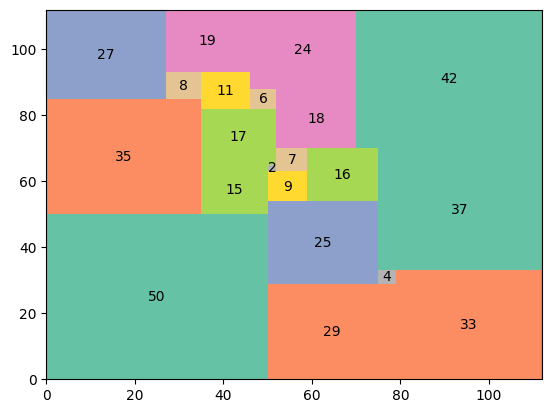

In [69]:
import docplex.cp.utils_visu as visu
import matplotlib.pyplot as plt
POP_UP_GRAPHIC=False
if msol and visu.is_visu_enabled():
    import matplotlib.cm as cm
    from matplotlib.patches import Polygon
    
    if not POP_UP_GRAPHIC:
        %matplotlib inline
    # Plot external square
    print("Plotting squares....")
    fig, ax = plt.subplots()
    plt.plot((0, 0), (0, SIZE_SQUARE), (SIZE_SQUARE, SIZE_SQUARE), (SIZE_SQUARE, 0))
    for i in range(len(SIZE_SUBSQUARE)):
        # Display square i
        (sx, sy) = (msol.get_var_solution(x[i]), msol.get_var_solution(y[i]))
        (sx1, sx2, sy1, sy2) = (sx.get_start(), sx.get_end(), sy.get_start(), sy.get_end())
        poly = Polygon([(sx1, sy1), (sx1, sy2), (sx2, sy2), (sx2, sy1)], fc=cm.Set2(float(i) / len(SIZE_SUBSQUARE)))
        ax.add_patch(poly)
        # Display identifier of square i at its center
        ax.text(float(sx1 + sx2) / 2, float(sy1 + sy2) / 2, str(SIZE_SUBSQUARE[i]), ha='center', va='center')
    plt.margins(0)
    plt.show()

<div style="background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 12px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); overflow: hidden; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: #8ca4f3ff; padding: 15px 25px;">
        <h2 style="color: #ffffff; margin: 0; border: none; font-size: 24px; letter-spacing: 1px;">
            谢谢
        </h2>
</div>